XTrain2
Item 1/1:
     Patient_Id Exercise_Id                                  Skeleton_Sequence
0             1          E1  [[-0.003837984, -0.579281688, 0.010213038, -0....
1             1          E1  [[-0.006423568, -0.590631604, 0.007034406, -0....
2             1          E1  [[0.010297444, -0.57850194, 0.023338385, -0.60...
3             1          E1  [[-0.039400429, -0.541313469, -0.023210142, -0...
4             2          E1  [[0.002523404, -0.574687421, 0.021674899, -0.5...
..          ...         ...                                                ...
441          14          E5  [[0.018183682, -0.503416181, 0.036054168, -0.5...
442          14          E5  [[0.008919089, -0.529203534, 0.022257812321186...
443          14          E5  [[0.046009932, -0.537010968, 0.060299847, -0.5...
444          14          E5  [[0.034558345, -0.547864616, 0.049173623, -0.5...
445          14          E5  [[0.00171333, -0.546153963, 0.0175316613167524...
[446 rows x 3 columns]

YTrain2
shape: (14,)
[0 0 0 0 1 1 1 0 0 0 0 1 0 1]

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

CLASS_NAME = {
    0: "left",
    1: "right",
}

In [3]:
# Load data
X1 = pd.read_pickle("Xtrain2.pkl")
y = np.load("Ytrain2.npy")

Patients = np.stack(X1["Patient_Id"].values)
Exercises = np.stack(X1["Exercise_Id"].values)
Classes = np.stack([y[patient-1] for patient in Patients])

In [11]:
unique, counts = np.unique(y, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {CLASS_NAME[u]}: {c} samples")

Class Left: 9 samples
Class Right: 5 samples


Exercise Count for each patient

In [16]:
for patient in np.unique(Patients):
    class_name = CLASS_NAME[y[patient - 1]]
    print(f"\nPatient ID: {patient}, Impairment: {class_name}")

    patient_indices = np.where(Patients == patient)[0]
    patient_exercises = Exercises[patient_indices]
    
    unique_exercises, exercise_counts = np.unique(patient_exercises, return_counts=True)
    for ex, count in zip(unique_exercises, exercise_counts):
        print(f"  Exercise {ex}: {count} samples")


Patient ID: 1, Impairment: Left
  Exercise E1: 4 samples
  Exercise E2: 2 samples
  Exercise E3: 8 samples
  Exercise E4: 10 samples
  Exercise E5: 8 samples

Patient ID: 2, Impairment: Left
  Exercise E1: 3 samples
  Exercise E2: 6 samples
  Exercise E3: 5 samples
  Exercise E4: 8 samples
  Exercise E5: 7 samples

Patient ID: 3, Impairment: Left
  Exercise E1: 6 samples
  Exercise E2: 2 samples
  Exercise E3: 7 samples
  Exercise E4: 8 samples
  Exercise E5: 9 samples

Patient ID: 4, Impairment: Left
  Exercise E1: 4 samples
  Exercise E2: 4 samples
  Exercise E3: 8 samples
  Exercise E4: 7 samples
  Exercise E5: 10 samples

Patient ID: 5, Impairment: Right
  Exercise E1: 6 samples
  Exercise E2: 3 samples
  Exercise E3: 8 samples
  Exercise E4: 10 samples
  Exercise E5: 8 samples

Patient ID: 6, Impairment: Right
  Exercise E1: 3 samples
  Exercise E2: 5 samples
  Exercise E3: 7 samples
  Exercise E4: 5 samples
  Exercise E5: 9 samples

Patient ID: 7, Impairment: Right
  Exercise E1

Impairment distribution for each exercise

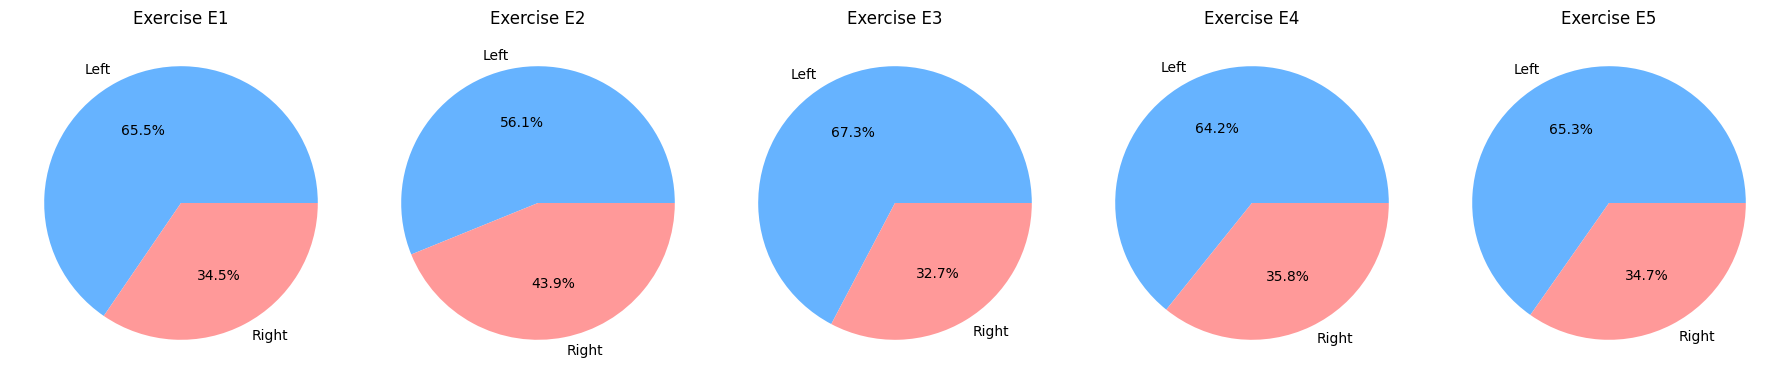

In [28]:
# Pie charts for class distribution per exercise
exercise_ids = np.unique(Exercises)
fig, axes = plt.subplots(1, len(exercise_ids), figsize=(18, 4))

for idx, ex_id in enumerate(exercise_ids):
    ex_indices = np.where(Exercises == ex_id)[0]
    ex_classes = Classes[ex_indices]
    class_counts = [np.sum(ex_classes == 0), np.sum(ex_classes == 1)]
    axes[idx].pie(class_counts, labels=[CLASS_NAME[0], CLASS_NAME[1]], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
    axes[idx].set_title(f'Exercise {ex_id}')

plt.tight_layout()
plt.show()

Extract features from sequence

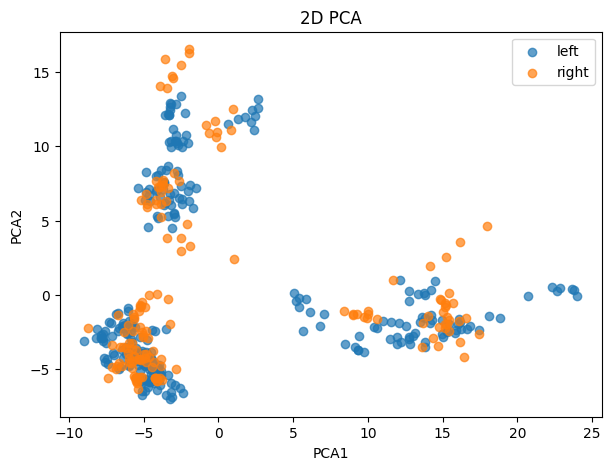

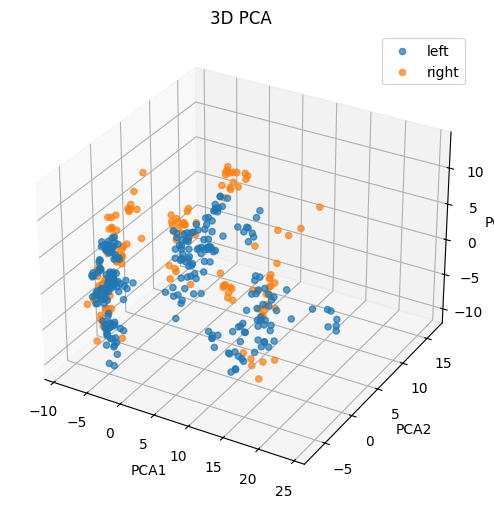

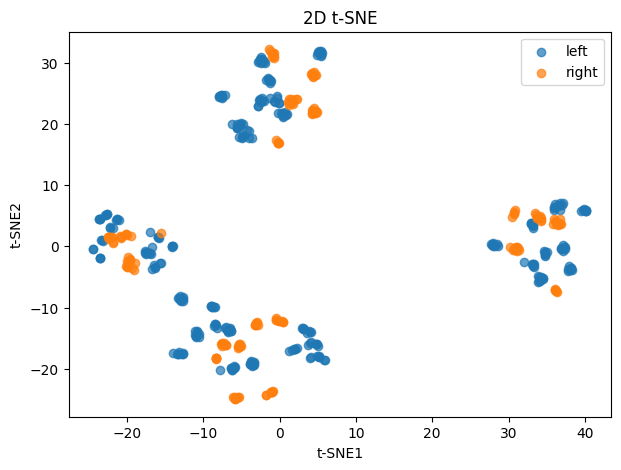

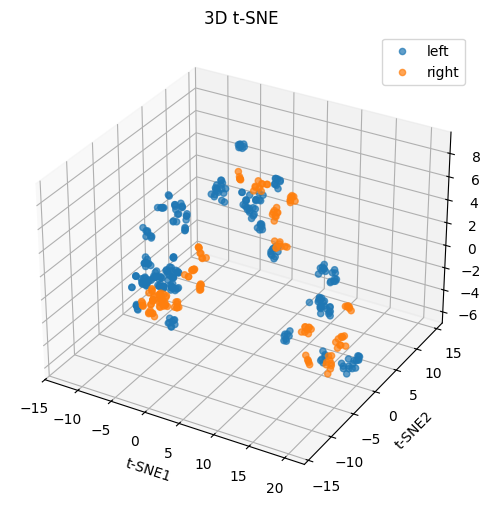

In [ ]:
def extract_features(X1):
    left_kps = [12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32]
    right_kps = [11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]
    shoulders = [11, 12]
    hips = [23, 24]

    means = np.zeros((len(X1), 33, 2))
    stds = np.zeros((len(X1), 33, 2))
    ranges = np.zeros((len(X1), 33))
    right_vs_left = np.zeros(len(X1))
    posture_angle = np.zeros(len(X1))

    # --- NEW features ---
    avg_speeds = np.zeros((len(X1), 33))
    travels = np.zeros((len(X1), 33))
    spd_mean = np.zeros((len(X1), 33))
    spd_std = np.zeros((len(X1), 33))
    acc_mean = np.zeros((len(X1), 33))
    acc_std = np.zeros((len(X1), 33))

    for i, sequence in enumerate(X1['Skeleton_Sequence'].values):
        sequence_array = np.array(sequence)
        sequence_array = sequence_array.reshape(-1, 33, 2)

        means[i] = np.mean(sequence_array, axis=0)
        stds[i] = np.std(sequence_array, axis=0)
        ranges[i] = np.linalg.norm(sequence_array.max(axis=0) - sequence_array.min(axis=0), axis=1)

        left_std_sum = np.sum(stds[i][left_kps][0]+ stds[i][left_kps][1])
        right_std_sum = np.sum(stds[i][right_kps][0]+ stds[i][right_kps][1])
        right_vs_left[i] = right_std_sum - left_std_sum

        # posture feature: angle between shoulders and hips (mean positions)
        shoulder_vec = means[i, shoulders[1]] - means[i, shoulders[0]]
        hip_vec = means[i, hips[1]] - means[i, hips[0]]
        torso_vec = (means[i, hips].mean(axis=0)) - (means[i, shoulders].mean(axis=0))
        # angle with respect to vertical axis (y)
        posture_angle[i] = np.arctan2(torso_vec[0], torso_vec[1])

        if sequence_array.shape[0] >= 2:
            v = np.diff(sequence_array, axis=0)
            spd = np.linalg.norm(v, axis=2)             
            avg_speeds[i] = np.mean(spd, axis=0)
            travels[i] = np.sum(spd, axis=0)
            spd_mean[i] = np.mean(spd, axis=0)
            spd_std[i] = np.std(spd, axis=0)

            if sequence_array.shape[0] >= 3:
                acc = np.diff(v, axis=0)
                accn = np.linalg.norm(acc, axis=2)
                acc_mean[i] = np.mean(accn, axis=0)
                acc_std[i] = np.std(accn, axis=0)

    return (
        means, stds, ranges, right_vs_left, posture_angle,
        avg_speeds, travels, spd_mean, spd_std,
        acc_mean, acc_std
    )

feats = extract_features(X1)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

features = np.concatenate([
    feats["means"].reshape(len(X1), -1),
    feats["stds"].reshape(len(X1), -1),
    feats["ranges"],
    feats["right_vs_left"][:, None],
    feats["posture_angle"][:, None],
    feats["avg_speeds"],
    feats["travels"],
    feats["spd_mean"], feats["spd_std"], 
    feats["acc_mean"], feats["acc_std"], 
], axis=1)

# Standardize
scaler = StandardScaler()
features_std = scaler.fit_transform(features)

# 2D PCA
pca2 = PCA(n_components=2)
pca2_result = pca2.fit_transform(features_std)

plt.figure(figsize=(7,5))
for c in np.unique(Classes):
    plt.scatter(pca2_result[Classes==c,0], pca2_result[Classes==c,1], label=CLASS_NAME[c], alpha=0.7)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('2D PCA')
plt.legend()
plt.show()

# 3D PCA
pca3 = PCA(n_components=3)
pca3_result = pca3.fit_transform(features_std)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
for c in np.unique(Classes):
    ax.scatter(pca3_result[Classes==c,0], pca3_result[Classes==c,1], pca3_result[Classes==c,2], label=CLASS_NAME[c], alpha=0.7)
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('3D PCA')
ax.legend()
plt.show()

# t-SNE (2D)
tsne2 = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
tsne2_result = tsne2.fit_transform(features_std)
plt.figure(figsize=(7,5))
for c in np.unique(Classes):
    plt.scatter(tsne2_result[Classes==c,0], tsne2_result[Classes==c,1], label=CLASS_NAME[c], alpha=0.7)
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.title('2D t-SNE')
plt.legend()
plt.show()

# t-SNE (3D)
tsne3 = TSNE(n_components=3, random_state=42, init='pca', learning_rate='auto')
tsne3_result = tsne3.fit_transform(features_std)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
for c in np.unique(Classes):
    ax.scatter(tsne3_result[Classes==c,0], tsne3_result[Classes==c,1], tsne3_result[Classes==c,2], label=CLASS_NAME[c], alpha=0.7)
ax.set_xlabel('t-SNE1')
ax.set_ylabel('t-SNE2')
ax.set_zlabel('t-SNE3')
ax.set_title('3D t-SNE')
ax.legend()
plt.show()

Vertical/Horizontal normalization (could try rotation)

In [72]:
means, stds, ranges, right_vs_left = extract_features(X1)

def normalize_features(means, stds):
    # Keypoint indices
    shoulders = [11, 12]
    hips = [23, 24]
    head = 0
    torso_indices = shoulders + hips

    # Compute torso centroid, shoulder distance, and vertical distance (per sample)
    centroid = means[:, torso_indices].mean(axis=1)  # (n_samples, 2)
    shoulder_dist = np.linalg.norm(means[:, shoulders[0]] - means[:, shoulders[1]], axis=1)
    mid_hip = means[:, hips].mean(axis=1)
    vert_dist = np.linalg.norm(means[:, head] - mid_hip, axis=1)

    # Avoid divide-by-zero
    shoulder_dist[shoulder_dist == 0] = 1
    vert_dist[vert_dist == 0] = 1

    # Normalize means (center + scale)
    means_centered = means - centroid[:, None, :]
    means_norm = np.empty_like(means_centered)
    means_norm[:, :, 0] = means_centered[:, :, 0] / shoulder_dist[:, None]
    means_norm[:, :, 1] = means_centered[:, :, 1] / vert_dist[:, None]

    # Normalize stds (scale only)
    stds_norm = np.empty_like(stds)
    stds_norm[:, :, 0] = stds[:, :, 0] / shoulder_dist[:, None]
    stds_norm[:, :, 1] = stds[:, :, 1] / vert_dist[:, None]

    # Normalize ranges (scale only)
    ranges_norm = ranges / (shoulder_dist + vert_dist)[:, None]

    # Normalize right_vs_left (scale only)
    right_vs_left_norm = right_vs_left / (shoulder_dist + vert_dist)

    return means_norm, stds_norm, ranges_norm, right_vs_left_norm

means_norm, stds_norm, ranges_norm, right_vs_left_norm = normalize_features(means, stds)

C:\Users\diogo\AppData\Local\Temp\ipykernel_62488\805381582.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


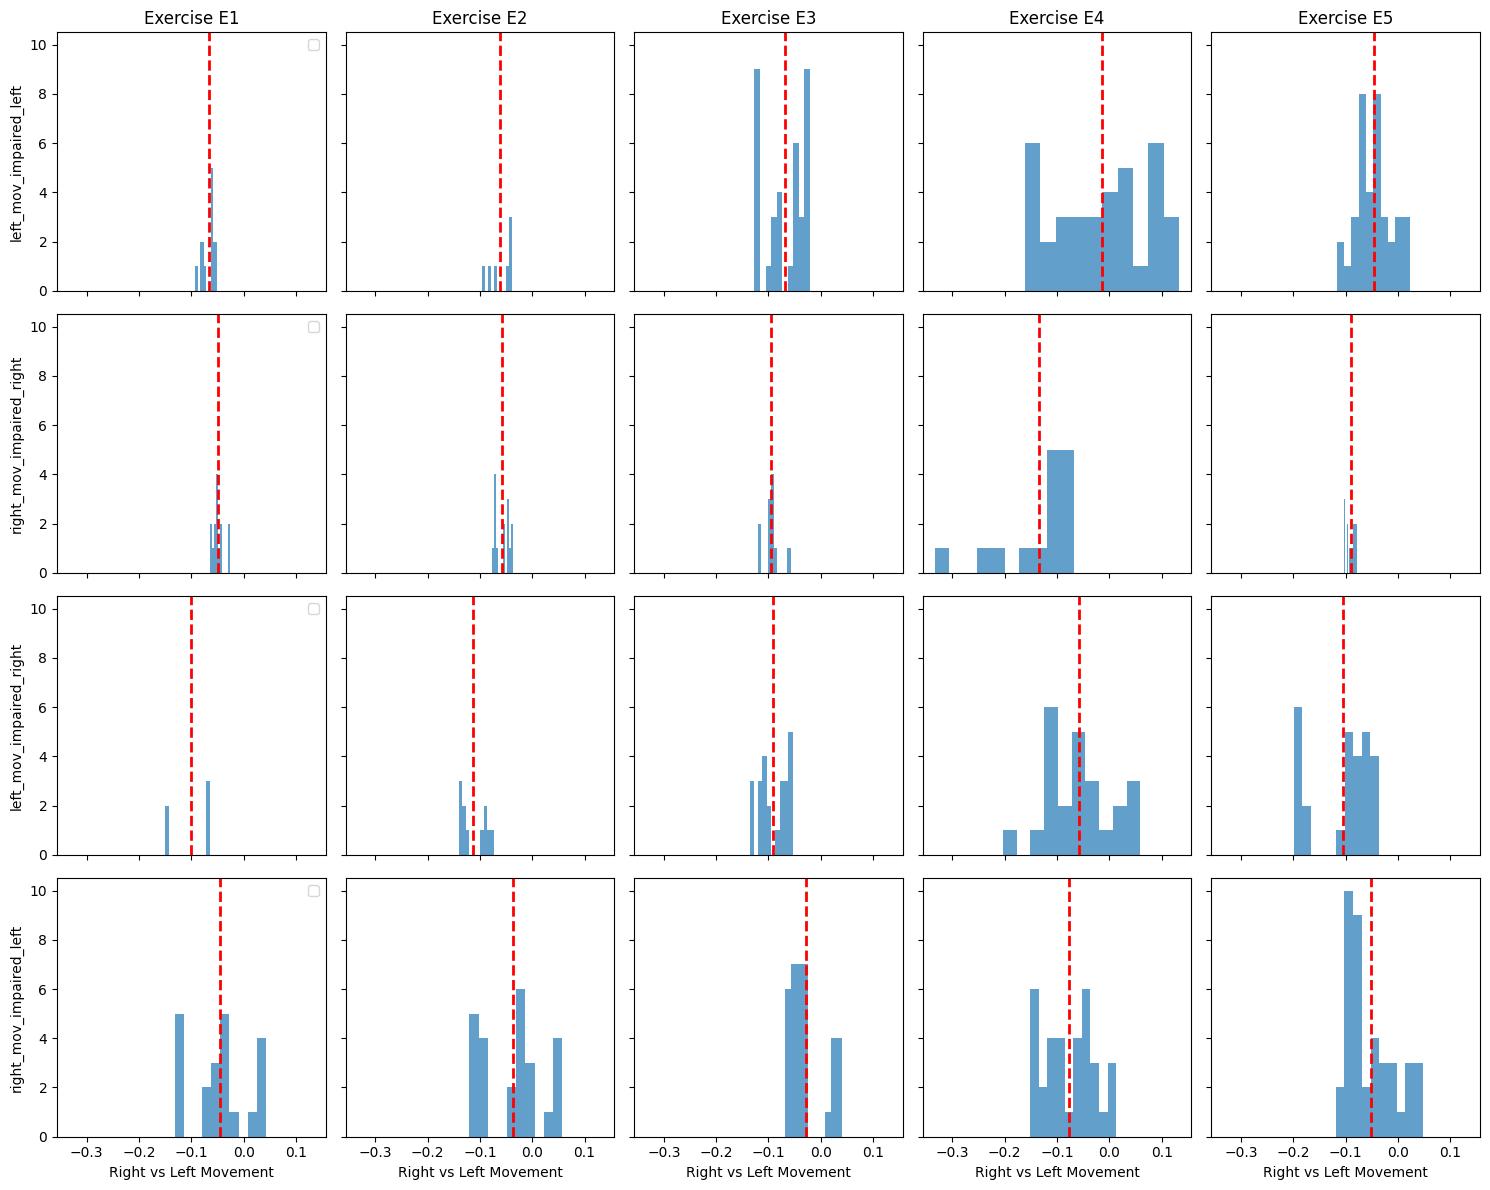

In [89]:
Classes_extended = Classes.copy()

CLASS_EXTENDED_NAME = {
    0: "left_mov_impaired_left",
    1: "right_mov_impaired_right",
    2: "left_mov_impaired_right",
    3: "right_mov_impaired_left",
}

left_arm = [14, 16, 18, 20, 22] 
right_arm = [13, 15, 17, 19, 21]

def detect_mov_side(stds):
    left_std_sum = np.sum(stds[left_arm])
    right_std_sum = np.sum(stds[right_arm])
    if left_std_sum >= right_std_sum:
        return 'left'
    else:
        return 'right'

for i, c in enumerate(Classes):
    if detect_mov_side(stds_norm[i]) == 'left' and CLASS_NAME[c] == "left":
        Classes_extended[i] = 0
    elif detect_mov_side(stds_norm[i]) == 'right' and CLASS_NAME[c] == "right":
        Classes_extended[i] = 1
    elif detect_mov_side(stds_norm[i]) == 'left' and CLASS_NAME[c] == "right":
        Classes_extended[i] = 2
    elif detect_mov_side(stds_norm[i]) == 'right' and CLASS_NAME[c] == "left":
        Classes_extended[i] = 3

exercise_ids = np.unique(Exercises)
n_exercises = len(exercise_ids)
n_classes = len(CLASS_EXTENDED_NAME)

fig, axes = plt.subplots(nrows=n_classes, ncols=n_exercises, figsize=(3*n_exercises, 3*n_classes), sharex=True, sharey=True)

for col, ex_id in enumerate(exercise_ids):
    for row, class_ext in enumerate(range(n_classes)):
        ax = axes[row, col]
        mask = (Exercises == ex_id) & (Classes_extended == class_ext)
        data = posture_angle[mask]
        if len(data) > 0:
            ax.hist(data, bins=10, alpha=0.7)
            ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2)
        if row == 0:
            ax.set_title(f'Exercise {ex_id}')
        if col == 0:
            ax.set_ylabel(CLASS_EXTENDED_NAME[class_ext])
        if row == n_classes-1:
            ax.set_xlabel('Right vs Left Movement')
        if col == 0:
            ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

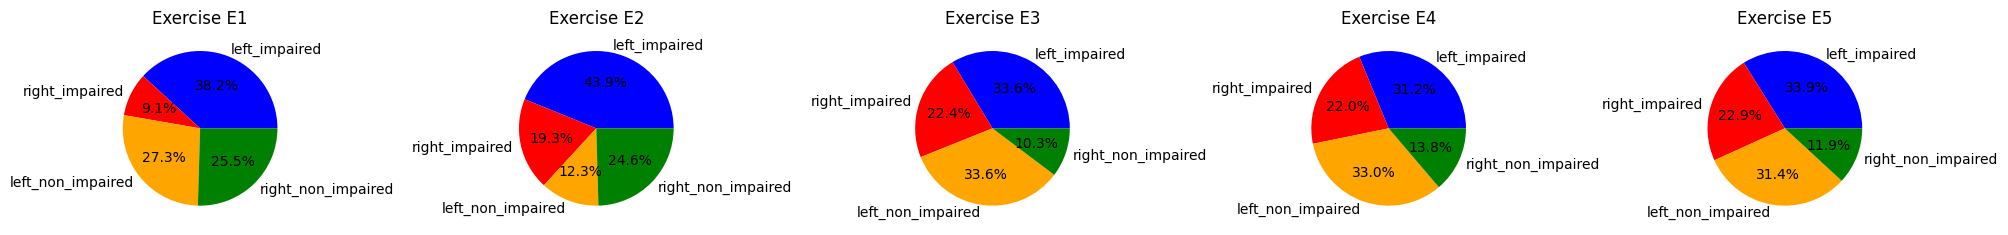

In [38]:
# Pie charts for extended class distribution per exercise
exercise_ids = np.unique(Exercises)
fig, axes = plt.subplots(1, len(exercise_ids), figsize=(4*len(exercise_ids), 4))

class_colors = {0: 'blue', 1: 'red', 2: 'orange', 3: 'green'}

for idx, ex_id in enumerate(exercise_ids):
    ex_indices = np.where(Exercises == ex_id)[0]
    ex_classes = Classes_extended[ex_indices]
    class_counts = [np.sum(ex_classes == k) for k in range(len(CLASS_EXTENDED_NAME))]
    labels = [CLASS_EXTENDED_NAME[k] for k in range(len(CLASS_EXTENDED_NAME))]
    colors = [class_colors[k] for k in range(len(CLASS_EXTENDED_NAME))]
    axes[idx].pie(class_counts, labels=labels, autopct='%1.1f%%', colors=colors)
    axes[idx].set_title(f'Exercise {ex_id}')

plt.tight_layout()
plt.show()

Plot one frame

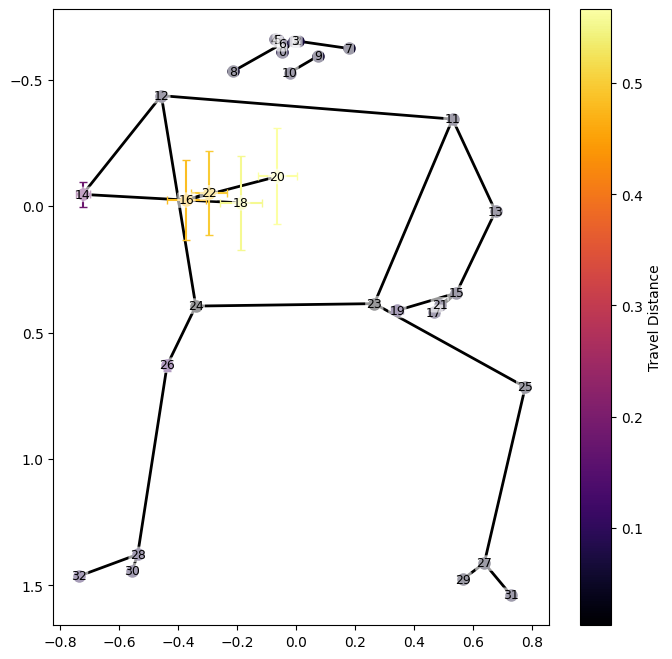

Right vs Left Movement: -0.0559
Posture Angle (radians): -0.0555


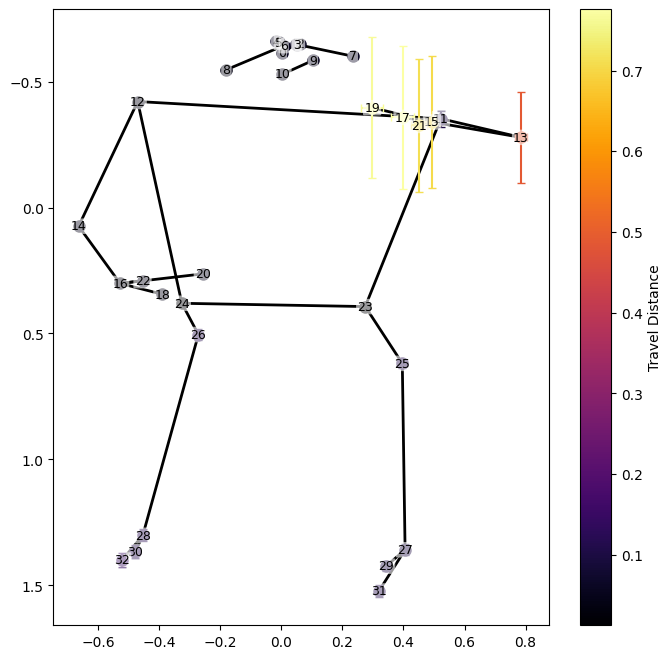

Right vs Left Movement: 0.2070
Posture Angle (radians): -0.0391


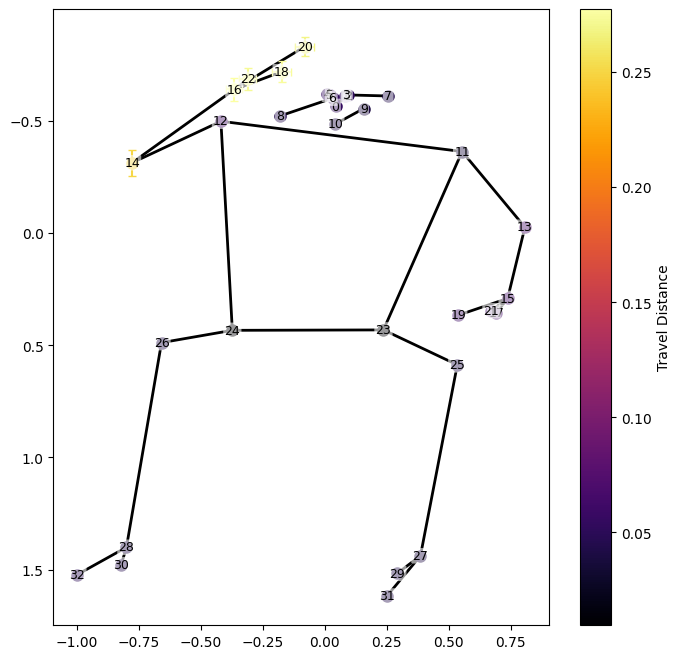

Right vs Left Movement: -0.0582
Posture Angle (radians): -0.0924


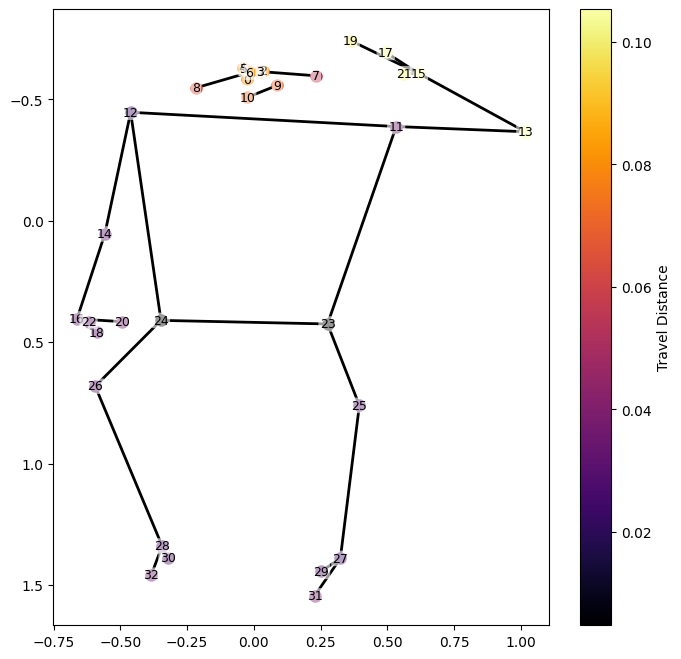

Right vs Left Movement: 0.0286
Posture Angle (radians): -0.0493


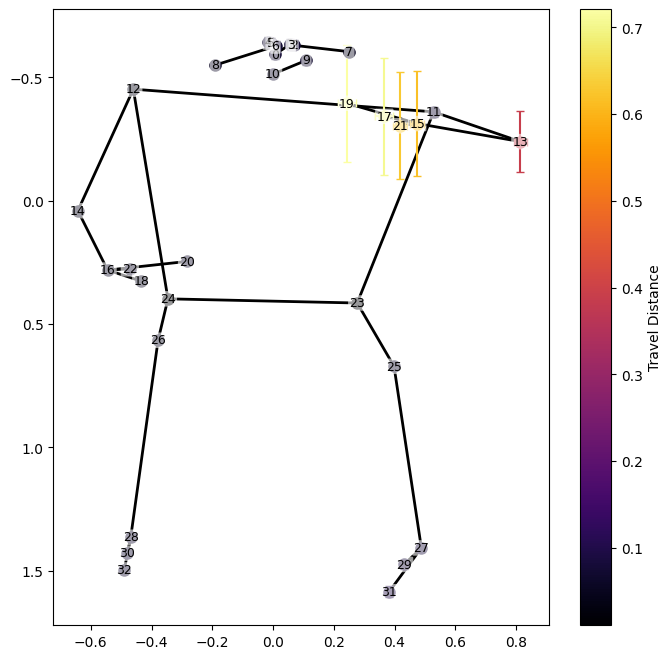

Right vs Left Movement: 0.1421
Posture Angle (radians): -0.0516


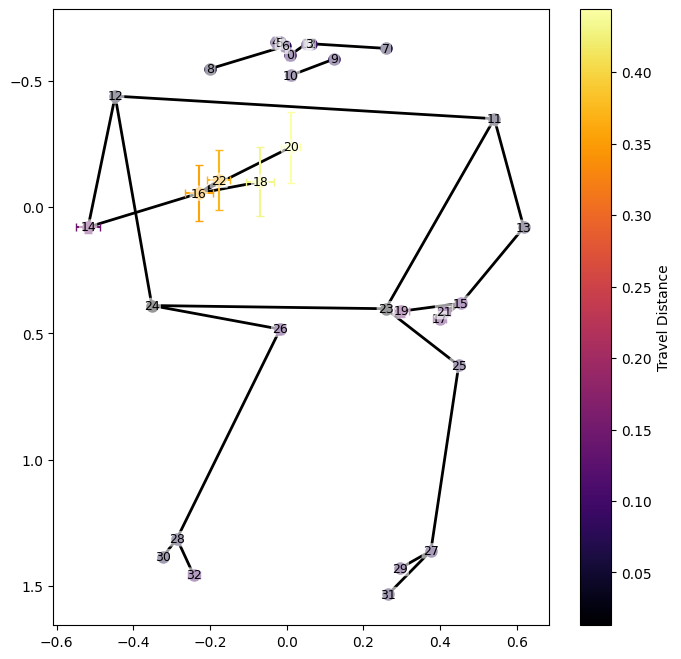

Right vs Left Movement: -0.0356
Posture Angle (radians): -0.0712


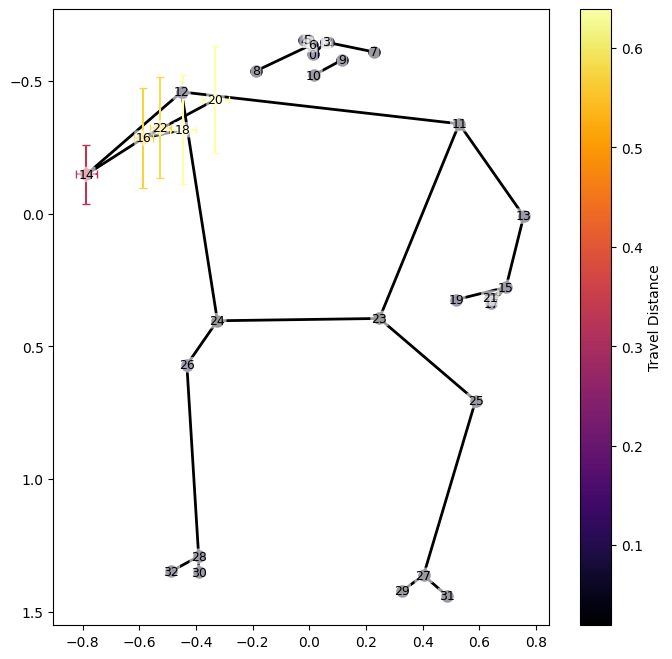

Right vs Left Movement: -0.1381
Posture Angle (radians): -0.0590


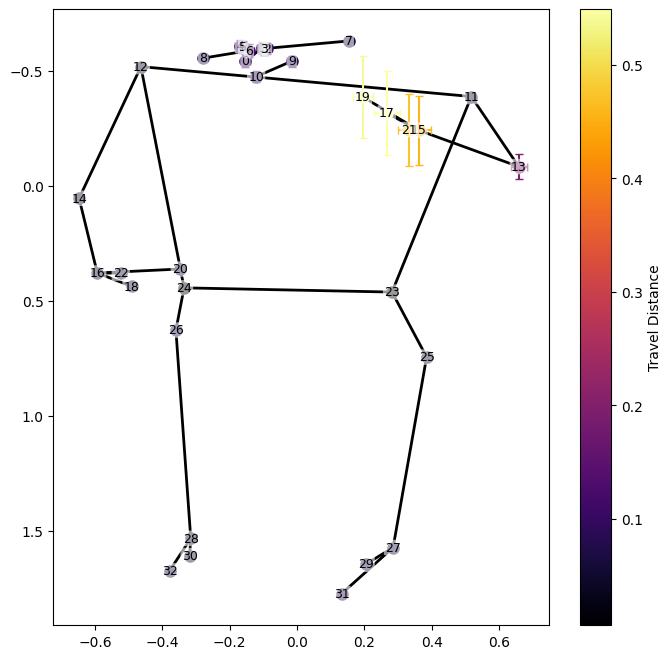

Right vs Left Movement: 0.0668
Posture Angle (radians): -0.0394


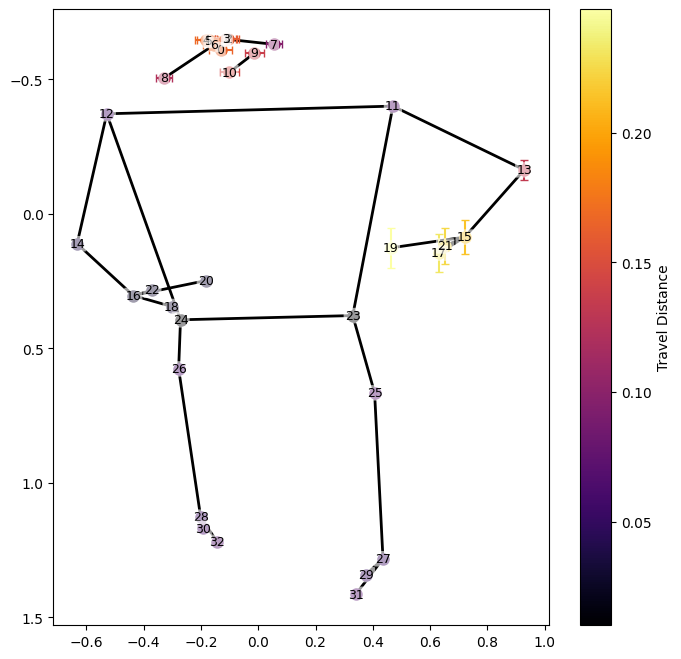

Right vs Left Movement: 0.0374
Posture Angle (radians): 0.0423


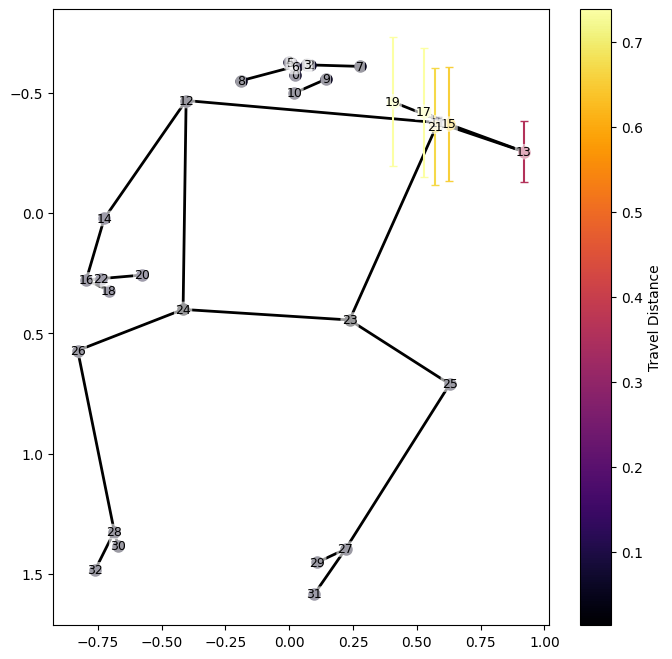

Right vs Left Movement: 0.1318
Posture Angle (radians): -0.1209


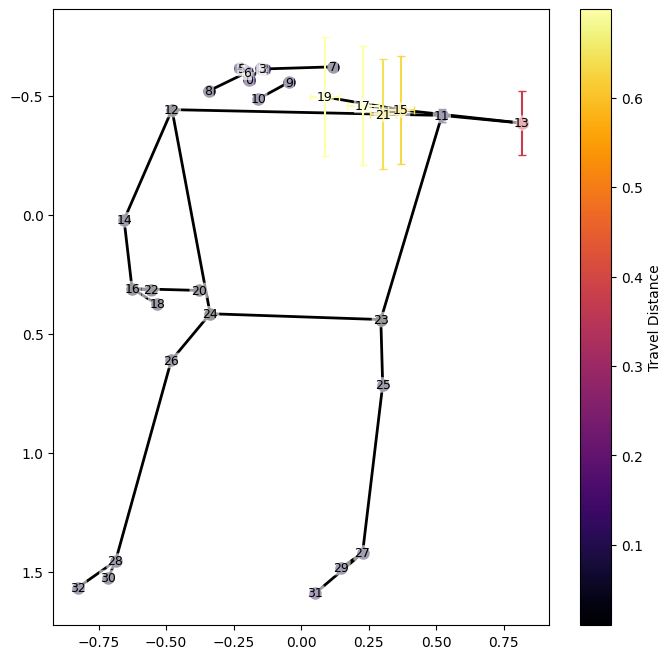

Right vs Left Movement: 0.1635
Posture Angle (radians): -0.0291


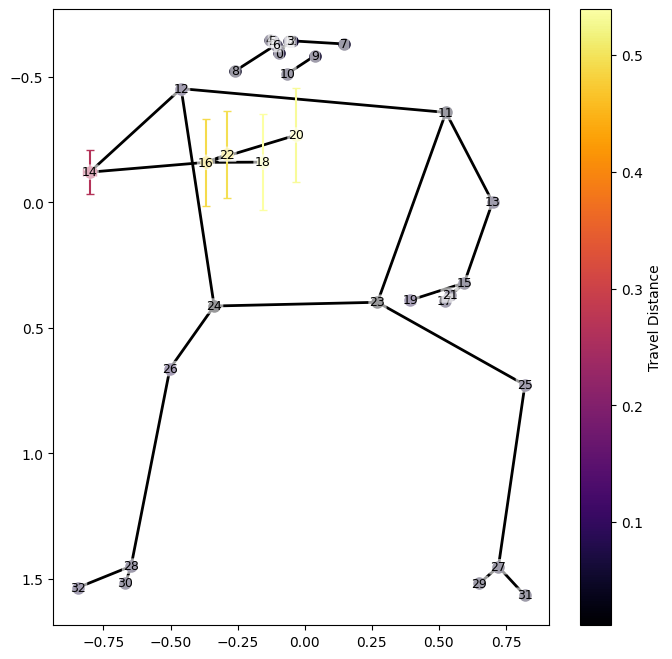

Right vs Left Movement: -0.0947
Posture Angle (radians): -0.0474


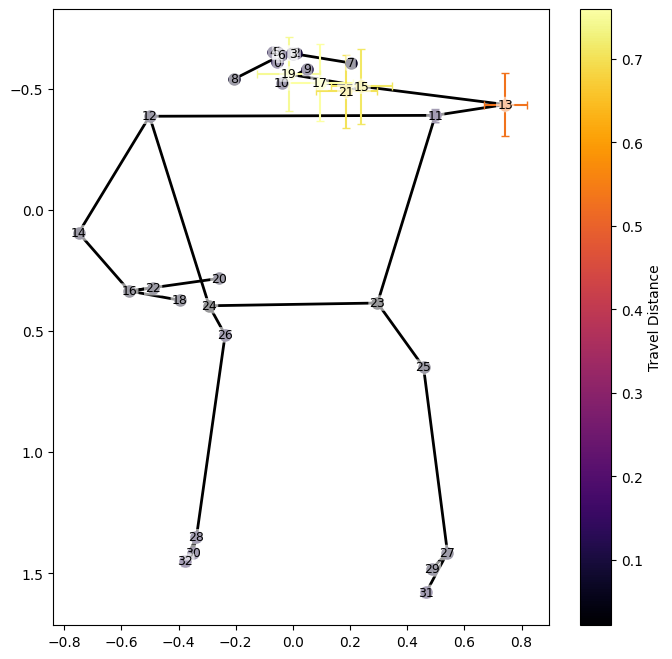

Right vs Left Movement: 0.2008
Posture Angle (radians): 0.0022


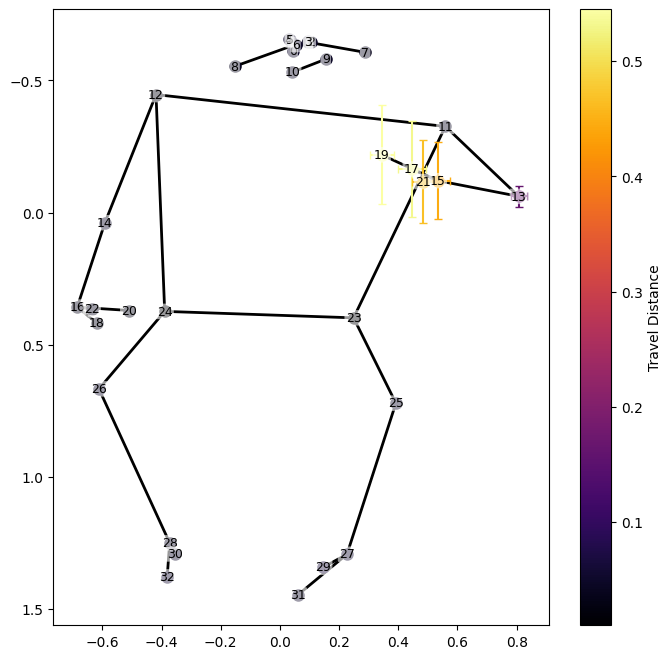

Right vs Left Movement: 0.0593
Posture Angle (radians): -0.1041


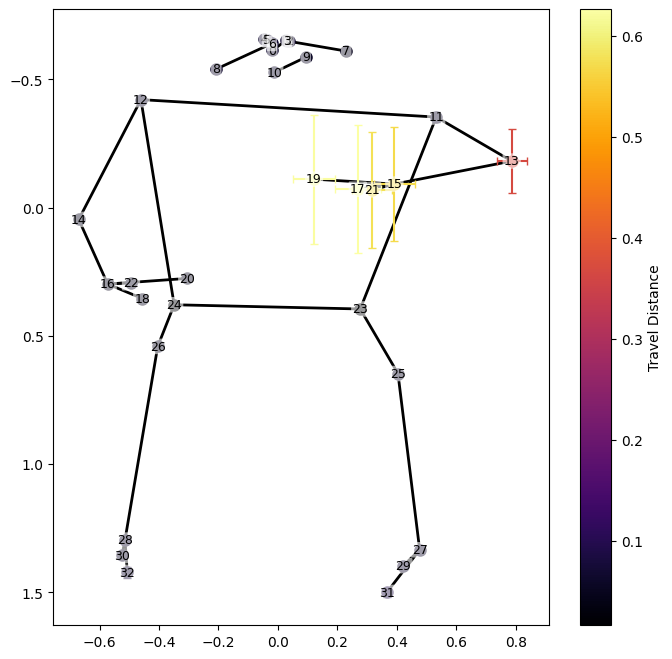

Right vs Left Movement: 0.1630
Posture Angle (radians): -0.0549


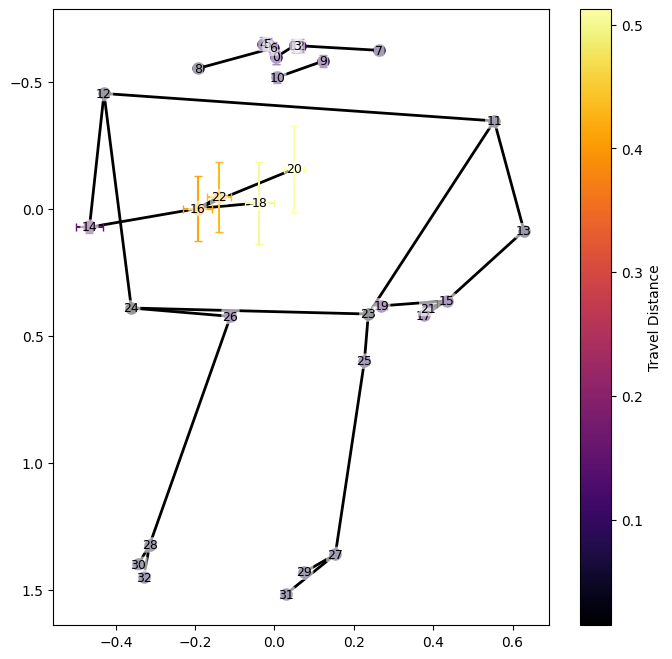

Right vs Left Movement: -0.0339
Posture Angle (radians): -0.0925


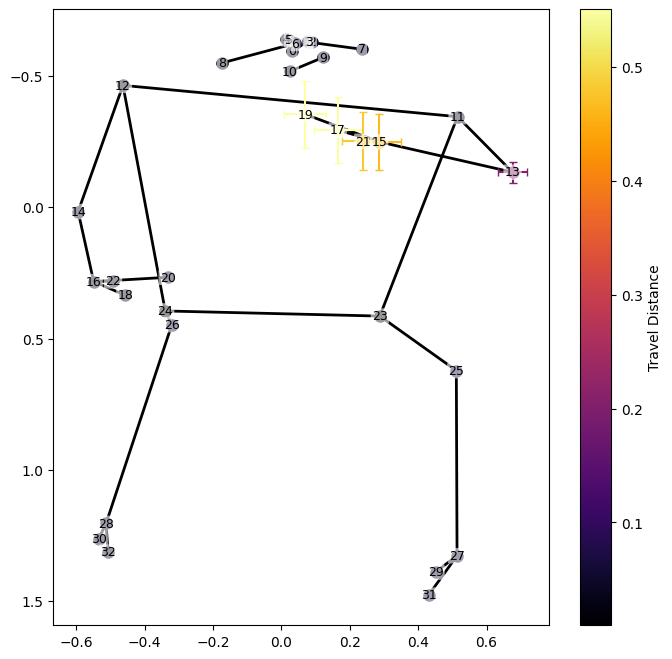

Right vs Left Movement: 0.0670
Posture Angle (radians): -0.0366


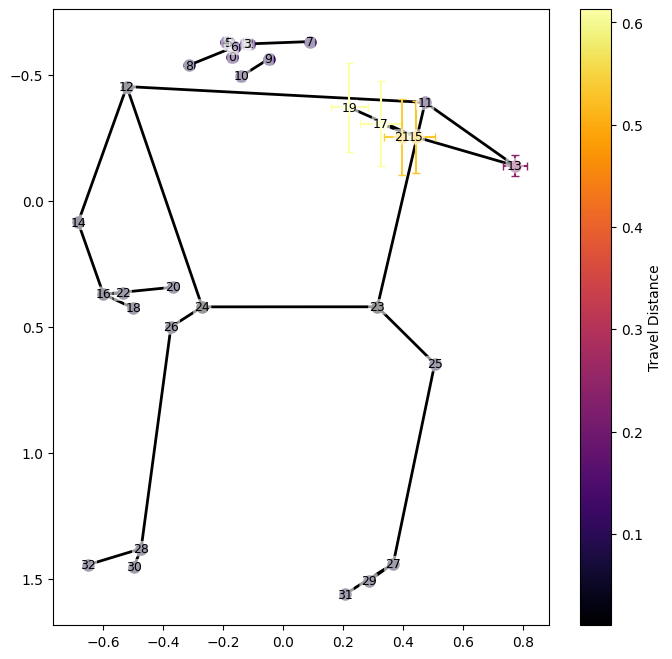

Right vs Left Movement: 0.0757
Posture Angle (radians): 0.0355


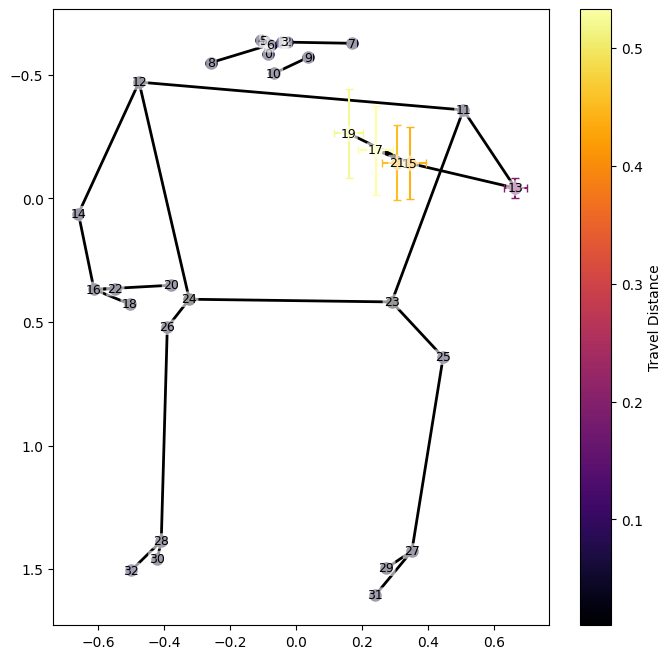

Right vs Left Movement: 0.0700
Posture Angle (radians): -0.0244


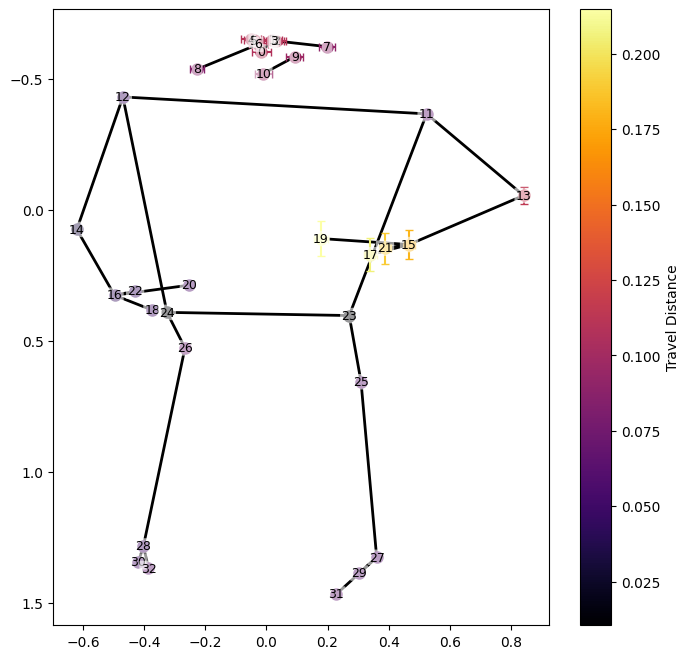

Right vs Left Movement: 0.0429
Posture Angle (radians): -0.0409


In [84]:
from matplotlib import cm

# Define skeleton edges
skeleton_edges = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),
    (11,12),(11,23),(12,24),(23,24),
    (11,13),(13,15),(15,17),(15,19),(15,21),
    (12,14),(14,16),(16,18),(16,20),(16,22),
    (23,25),(25,27),(27,29),(27,31),
    (24,26),(26,28),(28,30),(28,32)
]   

for id in range(0, 100, 5):

    plt.figure(figsize=(8, 8))
    ax = plt.gca()  # Get current axes
    ax.invert_yaxis()

    norm = plt.Normalize(ranges[id].min(), ranges[id].max())
    cmap = cm.inferno

    for kp in range(33):
        color = cmap(norm(ranges[id, kp]))
        plt.errorbar(
            means_norm[id, kp, 0], means_norm[id, kp, 1],
            xerr=stds[id, kp, 0], yerr=stds[id, kp, 1],
            fmt='o', color=color, ecolor=color, capsize=3, markersize=8
        )
        plt.text(
            means_norm[id, kp, 0], means_norm[id, kp, 1], str(kp), fontsize=9, ha='center', va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, boxstyle='round,pad=0.1')
        )
    # Skeleton Edges
    for (i, j) in skeleton_edges:
        plt.plot([means_norm[id, i, 0], means_norm[id, j, 0]], [means_norm[id, i, 1], means_norm[id, j, 1]], 'k-', linewidth=2, zorder=1)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, label='Travel Distance', ax=ax)  # <-- Pass ax here

    plt.show()

    print(f"Right vs Left Movement: {right_vs_left[id]:.4f}")
    print(f"Posture Angle (radians): {posture_angle[id]:.4f}")